In [32]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
# Check Current Working Directory and List Files

import os; os.getcwd()
import os; os.listdir('.')

['API_ST.INT.ARVL_DS2_en_csv_v2_4621',
 'Climate Data_Japan COPY.xlsx',
 'Climate Data_Japan.csv',
 'Climate Data_Japan.xlsx',
 'Data Format.xlsx',
 'Inbound Tourist Data.xlsx',
 'Old Data',
 'Other Data',
 'Tourism Data_Japan.csv',
 'Tourism Data_Japan.xlsx',
 'Visit by Prefecture Data_Leisure_Japan.csv',
 'Visit by Prefecture Data_Overall_Japan.csv']

In [34]:
# Set to Project Folder

import os
os.chdir(r"C:\Users\harol\Desktop\MBA\Module 4\Machine Learning Business Application with Python\GMBA Python\Project\Data")

## Confirm
print(os.getcwd())
print(os.listdir('.'))

C:\Users\harol\Desktop\MBA\Module 4\Machine Learning Business Application with Python\GMBA Python\Project\Data
['API_ST.INT.ARVL_DS2_en_csv_v2_4621', 'Climate Data_Japan COPY.xlsx', 'Climate Data_Japan.csv', 'Climate Data_Japan.xlsx', 'Data Format.xlsx', 'Inbound Tourist Data.xlsx', 'Old Data', 'Other Data', 'Tourism Data_Japan.csv', 'Tourism Data_Japan.xlsx', 'Visit by Prefecture Data_Leisure_Japan.csv', 'Visit by Prefecture Data_Overall_Japan.csv']


In [35]:
# Loading Datasets

tourism_data = pd.read_csv(r"C:\Users\harol\Desktop\MBA\Module 4\Machine Learning Business Application with Python\GMBA Python\Project\Data\Tourism Data_Japan.csv")
climate_data = pd.read_csv(r"C:\Users\harol\Desktop\MBA\Module 4\Machine Learning Business Application with Python\GMBA Python\Project\Data\Climate Data_Japan.csv")

## Display Data
print(tourism_data.head())
print(tourism_data.tail())
print(climate_data.head())
print(climate_data.tail())
print(climate_data.iloc[10:15])

   Year Month Prefecture  Tourist (Japan)
0  2002   Jan      Tokyo           193396
1  2002   Feb      Tokyo           246832
2  2002   Mar      Tokyo           241138
3  2002   Apr      Tokyo           266858
4  2002   May      Tokyo           257757
     Year Month Prefecture  Tourist (Japan)
823  2024   Aug      Chiba          2646445
824  2024   Sep      Chiba          2544751
825  2024   Oct      Chiba          3021710
826  2024   Nov      Chiba          2922383
827  2024   Dec      Chiba          3280013
   Year Month Prefecture Max Temp (°C) Min Temp (°C) Precipitation (mm)  \
0  2002   Jan      Tokyo          11.5           3.4               98.5   
1  2002   Feb      Tokyo          11.9           4.4                 25   
2  2002   Mar      Tokyo          16.5           8.1                 82   
3  2002   Apr      Tokyo          20.3          12.4                 58   
4  2002   May      Tokyo          22.3          15.3              112.5   

  Snowfall Depth (cm) Humidity (%

In [36]:
# Data Cleansing

## Replace "--" with 0 in tourism_data and climate_data
tourism_data = tourism_data.replace("--", 0)
climate_data = climate_data.replace("--", 0)

## Remove parentheses from all object columns in climate_data
def clean_parentheses_and_spaces(df):
    obj_cols = df.select_dtypes(include="object").columns
    df[obj_cols] = (
        df[obj_cols]
        .apply(lambda col: col.str.strip())                          # remove leading/trailing spaces
        .apply(lambda col: col.str.replace(r"[()]", "", regex=True))  # remove ( and )
        .apply(lambda col: col.str.replace(r"\s+", "", regex=True))   # optional remove all spaces, if needed
    )
    return df

climate_data = clean_parentheses_and_spaces(climate_data)

## Convert all columns in climate_data to numeric, coercing errors to NaN
for col in climate_data.columns:
    climate_data[col] = pd.to_numeric(climate_data[col], errors="ignore")

climate_data = climate_data.fillna(0)

## Display the cleaned data
print(tourism_data.head())
print(tourism_data.tail())
print(climate_data.head())
print(climate_data.tail())
print(climate_data.iloc[10:15])

   Year Month Prefecture  Tourist (Japan)
0  2002   Jan      Tokyo           193396
1  2002   Feb      Tokyo           246832
2  2002   Mar      Tokyo           241138
3  2002   Apr      Tokyo           266858
4  2002   May      Tokyo           257757
     Year Month Prefecture  Tourist (Japan)
823  2024   Aug      Chiba          2646445
824  2024   Sep      Chiba          2544751
825  2024   Oct      Chiba          3021710
826  2024   Nov      Chiba          2922383
827  2024   Dec      Chiba          3280013
   Year Month Prefecture  Max Temp (°C)  Min Temp (°C)  Precipitation (mm)  \
0  2002   Jan      Tokyo           11.5            3.4                98.5   
1  2002   Feb      Tokyo           11.9            4.4                25.0   
2  2002   Mar      Tokyo           16.5            8.1                82.0   
3  2002   Apr      Tokyo           20.3           12.4                58.0   
4  2002   May      Tokyo           22.3           15.3               112.5   

  Snowfall Dept

C:\Users\harol\AppData\Local\Temp\ipykernel_23804\226208430.py:22: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  climate_data[col] = pd.to_numeric(climate_data[col], errors="ignore")


In [37]:
# Create Tourist by Prefecture Column

## Define prefecture visit rate mapping
prefecture_rates = {
    'Tokyo': 48.3346/100,
    'Osaka': 43.0399/100,
    'Chiba': 35.5781/100
}
## Ensure Prefecture column exists and is clean
tourism_data['Prefecture'] = tourism_data['Prefecture'].astype(str).str.strip()

## Create Prefecture Visit Rate column
tourism_data['Prefecture Visit Rate'] = tourism_data['Prefecture'].map(prefecture_rates).fillna(0)

## Ensure Tourist (Japan) is numeric
tourism_data['Tourist (Japan)'] = pd.to_numeric(tourism_data['Tourist (Japan)'], errors='coerce').fillna(0)

## Create weighted Tourist column: Tourist (Japan) * Prefecture Visit Rate / 100
tourism_data['Tourist'] = tourism_data['Tourist (Japan)'] * (tourism_data['Prefecture Visit Rate'] / 100)

## Round Tourist to whole numbers (nearest integer)
tourism_data['Tourist'] = tourism_data['Tourist'].round(0).astype(int)

## Reorder: Prefecture Visit Rate after Tourist (Japan), then Tourist after
tourist_japan_loc = tourism_data.columns.get_loc('Tourist (Japan)')
cols = list(tourism_data.columns)

## Move Prefecture Visit Rate after Tourist (Japan)
cols.insert(tourist_japan_loc + 1, cols.pop(cols.index('Prefecture Visit Rate')))
## Move Tourist after Prefecture Visit Rate
new_pvr_loc = cols.index('Prefecture Visit Rate')
cols.insert(new_pvr_loc + 1, cols.pop(cols.index('Tourist')))

tourism_data = tourism_data[cols]

## Verify
print(tourism_data[['Tourist (Japan)', 'Prefecture Visit Rate', 'Tourist']].tail(10))

     Tourist (Japan)  Prefecture Visit Rate  Tourist
818          2771105               0.355781     9859
819          2763384               0.355781     9832
820          2758219               0.355781     9813
821          2913631               0.355781    10366
822          3055187               0.355781    10870
823          2646445               0.355781     9416
824          2544751               0.355781     9054
825          3021710               0.355781    10751
826          2922383               0.355781    10397
827          3280013               0.355781    11670


In [38]:
# Create Average Temperature Column

## ensure numeric
climate_data["Max Temp (°C)"] = pd.to_numeric(climate_data["Max Temp (°C)"], errors="coerce")
climate_data["Min Temp (°C)"] = pd.to_numeric(climate_data["Min Temp (°C)"], errors="coerce")

## calculate average
climate_data["Ave Temp (°C)"] = (climate_data["Max Temp (°C)"] + climate_data["Min Temp (°C)"]) / 2

## move column after Min Temp (°C)
min_loc = climate_data.columns.get_loc("Min Temp (°C)")
cols = list(climate_data.columns)
cols.insert(min_loc + 1, cols.pop(cols.index("Ave Temp (°C)")))
climate_data = climate_data[cols]

## verify
print(climate_data.columns.tolist())
print(climate_data[["Max Temp (°C)", "Min Temp (°C)", "Ave Temp (°C)"]].head())

['Year', 'Month', 'Prefecture', 'Max Temp (°C)', 'Min Temp (°C)', 'Ave Temp (°C)', 'Precipitation (mm)', 'Snowfall Depth (cm)', 'Humidity (%)', 'Windspeed (m/s)']
   Max Temp (°C)  Min Temp (°C)  Ave Temp (°C)
0           11.5            3.4           7.45
1           11.9            4.4           8.15
2           16.5            8.1          12.30
3           20.3           12.4          16.35
4           22.3           15.3          18.80


In [39]:
# Create Rainfall Column

## Ensure precipitation is numeric
climate_data["Precipitation (mm)"] = pd.to_numeric(climate_data["Precipitation (mm)"], errors="coerce").fillna(0)

## Define category logic
conditions = [
    climate_data["Precipitation (mm)"] > 160,
    climate_data["Precipitation (mm)"].between(90, 160, inclusive="both"),
    climate_data["Precipitation (mm)"].between(30, 90, inclusive="left"),  # 30 <= x < 90
    climate_data["Precipitation (mm)"].between(5, 30, inclusive="left"),   # 5 <= x < 30
]
choices = ["Heavy", "High", "Moderate", "Low"]

climate_data["Rainfall"] = np.select(conditions, choices, default="Very Low")

## Reorder so Rainfall is immediately after Precipitation (mm)
precip_loc = climate_data.columns.get_loc("Precipitation (mm)")
cols = list(climate_data.columns)
cols.insert(precip_loc + 1, cols.pop(cols.index("Rainfall")))
climate_data = climate_data[cols]

## Verify
print(climate_data[["Precipitation (mm)", "Rainfall"]].head(10))

   Precipitation (mm)  Rainfall
0                98.5      High
1                25.0       Low
2                82.0  Moderate
3                58.0  Moderate
4               112.5      High
5               151.5      High
6               124.0      High
7               120.0      High
8               207.0     Heavy
9               194.0     Heavy


In [40]:
# Merging Data

key = ['Year', 'Month', 'Prefecture']
tourism_climate = pd.merge(tourism_data, climate_data, on=key, how='inner', validate='one_to_one')

## Display the merged data
print(tourism_climate.shape)
print(tourism_climate.head())
print(tourism_climate.tail())
print(tourism_climate.info())

(828, 14)
   Year Month Prefecture  Tourist (Japan)  Prefecture Visit Rate  Tourist  \
0  2002   Jan      Tokyo           193396               0.483346      935   
1  2002   Feb      Tokyo           246832               0.483346     1193   
2  2002   Mar      Tokyo           241138               0.483346     1166   
3  2002   Apr      Tokyo           266858               0.483346     1290   
4  2002   May      Tokyo           257757               0.483346     1246   

   Max Temp (°C)  Min Temp (°C)  Ave Temp (°C)  Precipitation (mm)  Rainfall  \
0           11.5            3.4           7.45                98.5      High   
1           11.9            4.4           8.15                25.0       Low   
2           16.5            8.1          12.30                82.0  Moderate   
3           20.3           12.4          16.35                58.0  Moderate   
4           22.3           15.3          18.80               112.5      High   

  Snowfall Depth (cm)  Humidity (%)  Windspeed

In [41]:
# Create Season Column

## Map month names to seasons
season_map = {
    'Dec': 'Winter', 'Jan': 'Winter', 'Feb': 'Winter',
    'Mar': 'Spring', 'Apr': 'Spring', 'May': 'Spring',
    'Jun': 'Summer', 'Jul': 'Summer', 'Aug': 'Summer',
    'Sep': 'Autumn', 'Oct': 'Autumn', 'Nov': 'Autumn'
}

## if month values have full names or whitespace, normalize first
tourism_climate['Month'] = tourism_climate['Month'].astype(str).str.strip().str[:3].str.capitalize()

## create Season
tourism_climate['Season'] = tourism_climate['Month'].map(season_map).fillna('Unknown')

## move Season after Month
month_loc = tourism_climate.columns.get_loc('Month')
cols = list(tourism_climate.columns)
cols.insert(month_loc + 1, cols.pop(cols.index('Season')))
tourism_climate = tourism_climate[cols]

## verify
print(tourism_climate[['Month', 'Season']].head(10))

  Month  Season
0   Jan  Winter
1   Feb  Winter
2   Mar  Spring
3   Apr  Spring
4   May  Spring
5   Jun  Summer
6   Jul  Summer
7   Aug  Summer
8   Sep  Autumn
9   Oct  Autumn


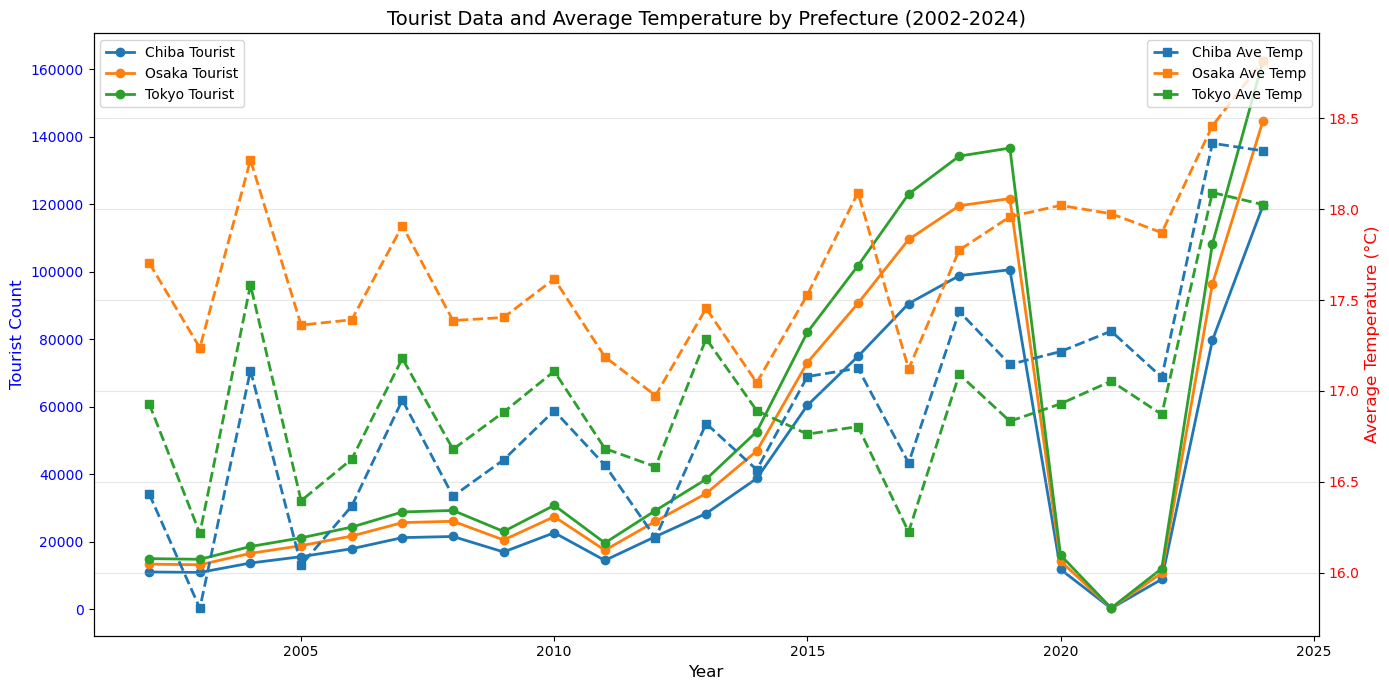

Summary of Tourist and Temperature by Prefecture:
             Tourist          Ave Temp (°C)
                mean      sum          mean
Prefecture                                 
Chiba       39104.61   899406         16.89
Osaka       47305.57  1088028         17.68
Tokyo       53125.13  1221878         16.94


In [42]:
# Visualization: Tourist Data vs Average Temperature by Prefecture (2002-2024)

# Group by Year and Prefecture, aggregate Tourist (sum) and Ave Temp (mean)
grouped = tourism_climate.groupby(['Year', 'Prefecture']).agg({
    'Tourist': 'sum',
    'Ave Temp (°C)': 'mean'
}).reset_index()

# Create dual-axis line chart
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot Tourist data (left y-axis)
for pref in grouped['Prefecture'].unique():
    data = grouped[grouped['Prefecture'] == pref]
    ax1.plot(data['Year'], data['Tourist'], marker='o', linewidth=2, label=f'{pref} Tourist')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Tourist Count', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

# Plot Average Temperature (right y-axis)
ax2 = ax1.twinx()
for pref in grouped['Prefecture'].unique():
    data = grouped[grouped['Prefecture'] == pref]
    ax2.plot(data['Year'], data['Ave Temp (°C)'], marker='s', linestyle='--', linewidth=2, label=f'{pref} Ave Temp')

ax2.set_ylabel('Average Temperature (°C)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.title('Tourist Data and Average Temperature by Prefecture (2002-2024)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: Print summary stats
print("Summary of Tourist and Temperature by Prefecture:")
summary = grouped.groupby('Prefecture').agg({
    'Tourist': ['mean', 'sum'],
    'Ave Temp (°C)': 'mean'
}).round(2)
print(summary)

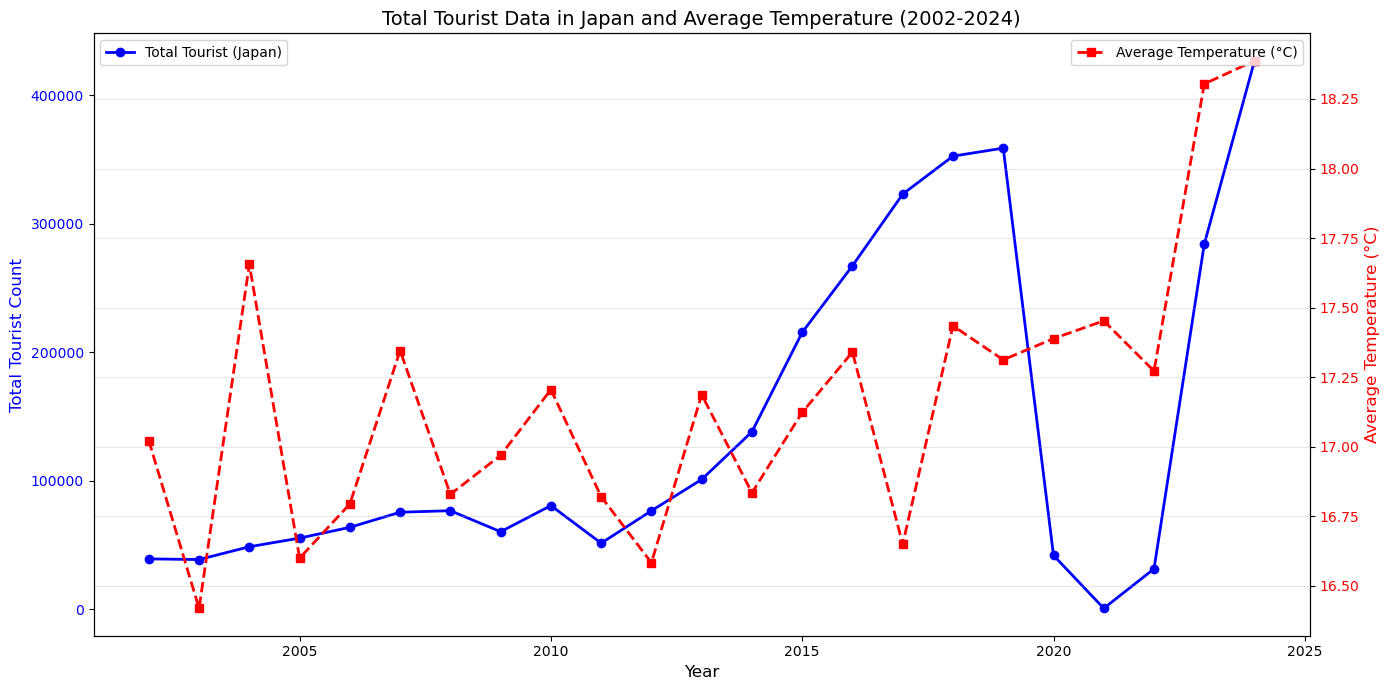

Yearly Summary:
    Year  Tourist  Ave Temp (°C)
0   2002    39296          17.02
1   2003    38784          16.42
2   2004    48745          17.66
3   2005    55458          16.60
4   2006    63850          16.79
5   2007    75590          17.35
6   2008    76790          16.83
7   2009    60428          16.97
8   2010    80764          17.21
9   2011    51511          16.82
10  2012    76700          16.58
11  2013   101087          17.19
12  2014   138132          16.83
13  2015   215428          17.12
14  2016   267228          17.34
15  2017   322989          16.65
16  2018   352500          17.43
17  2019   358733          17.31
18  2020    42049          17.39
19  2021      841          17.45
20  2022    31583          17.27
21  2023   284118          18.30
22  2024   426708          18.39


In [43]:
# Visualization: Total Tourist Data in Japan vs Average Temperature (2002-2024)

# Group by Year, aggregate total Tourist (sum) and average Ave Temp (mean across prefectures)
grouped_total = tourism_climate.groupby('Year').agg({
    'Tourist': 'sum',
    'Ave Temp (°C)': 'mean'
}).reset_index()

# Create dual-axis line chart
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot total Tourist data (left y-axis)
ax1.plot(grouped_total['Year'], grouped_total['Tourist'], marker='o', linewidth=2, color='blue', label='Total Tourist (Japan)')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Total Tourist Count', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

# Plot Average Temperature (right y-axis)
ax2 = ax1.twinx()
ax2.plot(grouped_total['Year'], grouped_total['Ave Temp (°C)'], marker='s', linestyle='--', linewidth=2, color='red', label='Average Temperature (°C)')

ax2.set_ylabel('Average Temperature (°C)', fontsize=12, color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.legend(loc='upper right')

plt.title('Total Tourist Data in Japan and Average Temperature (2002-2024)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: Print summary stats
print("Yearly Summary:")
summary_total = grouped_total.round(2)
print(summary_total)

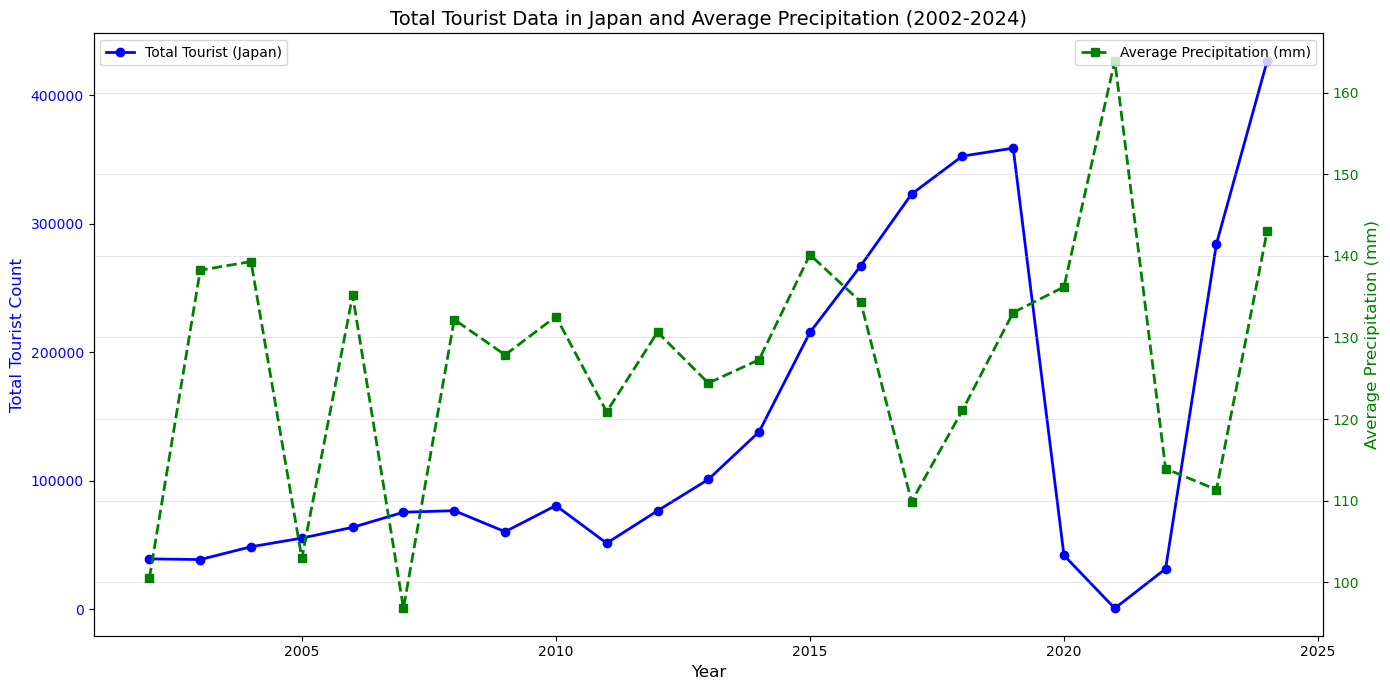

Yearly Summary:
    Year  Tourist  Precipitation (mm)
0   2002    39296              100.51
1   2003    38784              138.25
2   2004    48745              139.31
3   2005    55458              102.93
4   2006    63850              135.15
5   2007    75590               96.79
6   2008    76790              132.19
7   2009    60428              127.86
8   2010    80764              132.57
9   2011    51511              120.89
10  2012    76700              130.65
11  2013   101087              124.40
12  2014   138132              127.28
13  2015   215428              140.15
14  2016   267228              134.36
15  2017   322989              109.88
16  2018   352500              121.06
17  2019   358733              133.06
18  2020    42049              136.19
19  2021      841              163.93
20  2022    31583              113.92
21  2023   284118              111.35
22  2024   426708              143.07


In [44]:
# Visualization: Total Tourist Data in Japan vs Precipitation (Rainfall) (2002-2024)

# Group by Year, aggregate total Tourist (sum) and average Precipitation (mean across prefectures)
grouped_rain = tourism_climate.groupby('Year').agg({
    'Tourist': 'sum',
    'Precipitation (mm)': 'mean'
}).reset_index()

# Create dual-axis line chart
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot total Tourist data (left y-axis)
ax1.plot(grouped_rain['Year'], grouped_rain['Tourist'], marker='o', linewidth=2, color='blue', label='Total Tourist (Japan)')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Total Tourist Count', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

# Plot Average Precipitation (right y-axis)
ax2 = ax1.twinx()
ax2.plot(grouped_rain['Year'], grouped_rain['Precipitation (mm)'], marker='s', linestyle='--', linewidth=2, color='green', label='Average Precipitation (mm)')

ax2.set_ylabel('Average Precipitation (mm)', fontsize=12, color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.legend(loc='upper right')

plt.title('Total Tourist Data in Japan and Average Precipitation (2002-2024)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: Print summary stats
print("Yearly Summary:")
summary_rain = grouped_rain.round(2)
print(summary_rain)

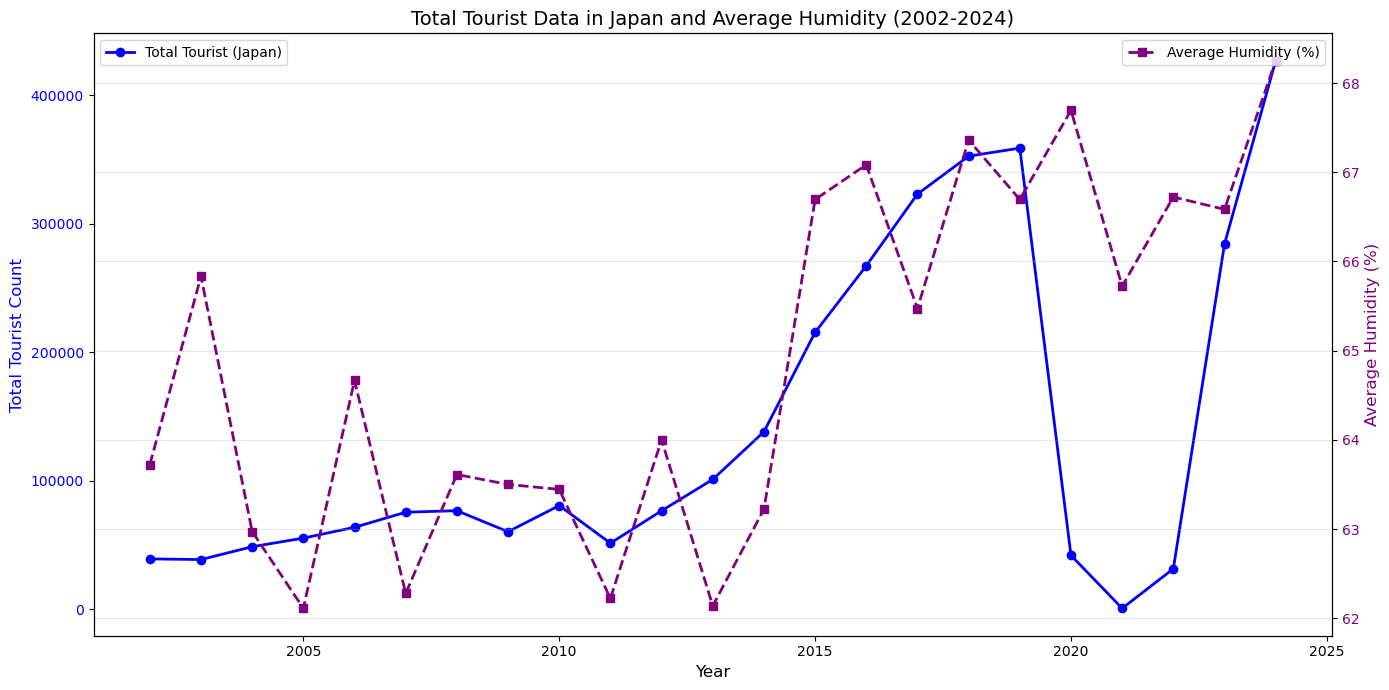

Yearly Summary:
    Year  Tourist  Humidity (%)
0   2002    39296         63.72
1   2003    38784         65.83
2   2004    48745         62.97
3   2005    55458         62.11
4   2006    63850         64.67
5   2007    75590         62.28
6   2008    76790         63.61
7   2009    60428         63.50
8   2010    80764         63.44
9   2011    51511         62.22
10  2012    76700         64.00
11  2013   101087         62.14
12  2014   138132         63.22
13  2015   215428         66.69
14  2016   267228         67.08
15  2017   322989         65.47
16  2018   352500         67.36
17  2019   358733         66.69
18  2020    42049         67.69
19  2021      841         65.72
20  2022    31583         66.72
21  2023   284118         66.58
22  2024   426708         68.25


In [45]:
# Visualization: Total Tourist Data in Japan vs Humidity (2002-2024)

# Group by Year, aggregate total Tourist (sum) and average Humidity (mean across prefectures)
grouped_humidity = tourism_climate.groupby('Year').agg({
    'Tourist': 'sum',
    'Humidity (%)': 'mean'
}).reset_index()

# Create dual-axis line chart
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot total Tourist data (left y-axis)
ax1.plot(grouped_humidity['Year'], grouped_humidity['Tourist'], marker='o', linewidth=2, color='blue', label='Total Tourist (Japan)')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Total Tourist Count', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

# Plot Average Humidity (right y-axis)
ax2 = ax1.twinx()
ax2.plot(grouped_humidity['Year'], grouped_humidity['Humidity (%)'], marker='s', linestyle='--', linewidth=2, color='purple', label='Average Humidity (%)')

ax2.set_ylabel('Average Humidity (%)', fontsize=12, color='purple')
ax2.tick_params(axis='y', labelcolor='purple')
ax2.legend(loc='upper right')

plt.title('Total Tourist Data in Japan and Average Humidity (2002-2024)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: Print summary stats
print("Yearly Summary:")
summary_humidity = grouped_humidity.round(2)
print(summary_humidity)

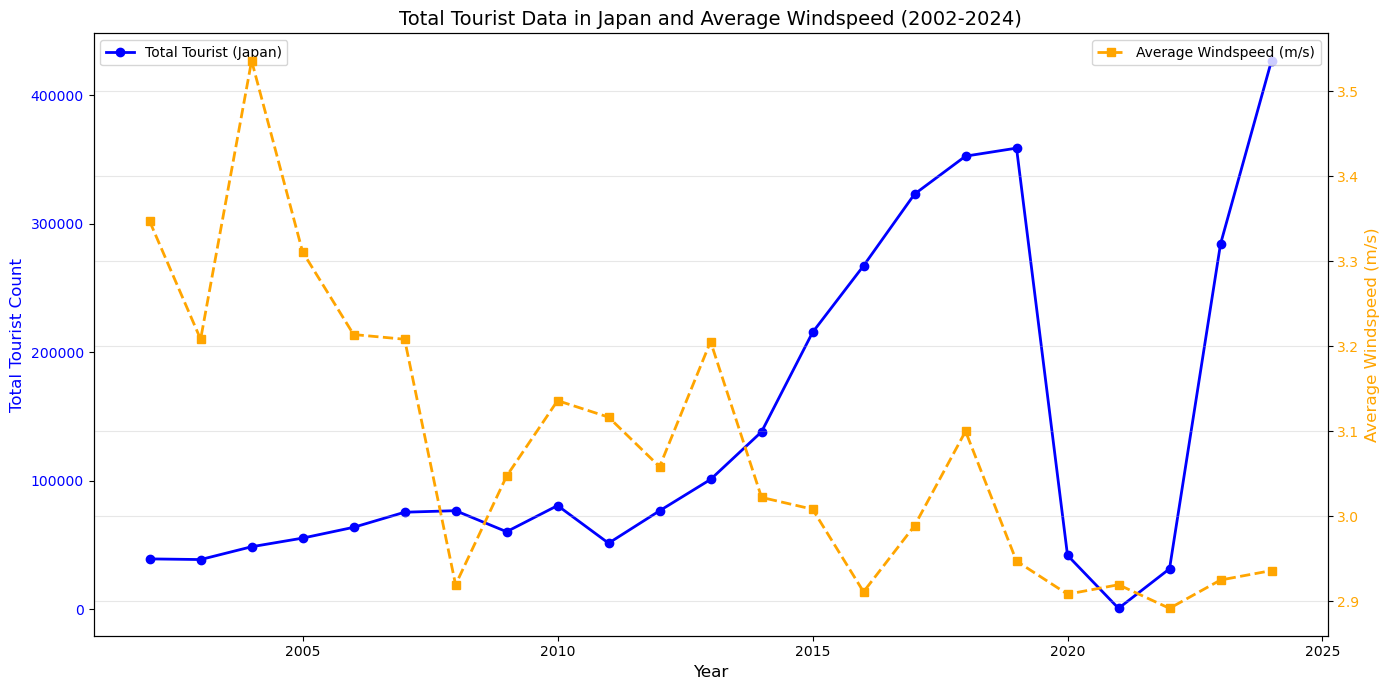

Yearly Summary:
    Year  Tourist  Windspeed (m/s)
0   2002    39296             3.35
1   2003    38784             3.21
2   2004    48745             3.54
3   2005    55458             3.31
4   2006    63850             3.21
5   2007    75590             3.21
6   2008    76790             2.92
7   2009    60428             3.05
8   2010    80764             3.14
9   2011    51511             3.12
10  2012    76700             3.06
11  2013   101087             3.21
12  2014   138132             3.02
13  2015   215428             3.01
14  2016   267228             2.91
15  2017   322989             2.99
16  2018   352500             3.10
17  2019   358733             2.95
18  2020    42049             2.91
19  2021      841             2.92
20  2022    31583             2.89
21  2023   284118             2.92
22  2024   426708             2.94


In [46]:
# Visualization: Total Tourist Data in Japan vs Windspeed (2002-2024)

# Group by Year, aggregate total Tourist (sum) and average Windspeed (mean across prefectures)
grouped_wind = tourism_climate.groupby('Year').agg({
    'Tourist': 'sum',
    'Windspeed (m/s)': 'mean'
}).reset_index()

# Create dual-axis line chart
fig, ax1 = plt.subplots(figsize=(14, 7))

# Plot total Tourist data (left y-axis)
ax1.plot(grouped_wind['Year'], grouped_wind['Tourist'], marker='o', linewidth=2, color='blue', label='Total Tourist (Japan)')

ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Total Tourist Count', fontsize=12, color='blue')
ax1.tick_params(axis='y', labelcolor='blue')
ax1.legend(loc='upper left')

# Plot Average Windspeed (right y-axis)
ax2 = ax1.twinx()
ax2.plot(grouped_wind['Year'], grouped_wind['Windspeed (m/s)'], marker='s', linestyle='--', linewidth=2, color='orange', label='Average Windspeed (m/s)')

ax2.set_ylabel('Average Windspeed (m/s)', fontsize=12, color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.legend(loc='upper right')

plt.title('Total Tourist Data in Japan and Average Windspeed (2002-2024)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Optional: Print summary stats
print("Yearly Summary:")
summary_wind = grouped_wind.round(2)
print(summary_wind)